# **PARTE A – Regresión lineal**

## **Práctica**
En una secuencia de tiempo de **10 minutos**, disponemos de un **sensor de temperatura inteligente**
instalado en una sala. El sensor mide la **temperatura ambiente (T)** cada cierto intervalo de tiempo.
Nos interesa calcular la **regresión lineal** de los pares $tiempo–temperatura$ para analizar si la
temperatura está aumentando o disminuyendo de forma progresiva (por ejemplo, debido a la
activación de un sistema de calefacción).

---

## **El primer paso**

El primer paso consistirá en **generar datos realistas** a partir de un coeficiente de tendencia y una
variación aleatoria que simule el ruido del sensor. Para ello, se debe generar:

* Un array **x** con los instantes de tiempo (por ejemplo, de 1 a 600, representando los segundos
de 10 minutos).

* Un array **y** con los valores de temperatura correspondientes a cada instante.

### 1. Carga de librerías

In [1]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
import pandas as pd
import seaborn as sns

### 2. Generar array x: instantes de tiempo de 1 a 600 inclusive.
> Nota: `np.arange(inicio, fin)` no incluye el valor final, por eso usamos 601

In [3]:
x = np.arange(1, 601)

### 3. Generar el ruido aleatorio para cada instante (entre -0.8 y 0.8)
> Nota: Al utilizar `np.random.uniform`, nos aseguramos de que cualquier valor dentro de ese rango tenga la misma probabilidad de aparecer, simulando una imprecisión constante del hardware.

In [4]:
ruido = np.random.uniform(-0.8, 0.8, size=len(x))


 ### 4. Aplicar la fórmula:
 $$T = 0.02 * x + 20 + ruido$$
  > Nota: Gracias a `NumPy`, la operación se aplica a todo el array automáticamente


In [5]:
y = 0.02 * x + 20 + ruido

### 5. Salida de los primeros 5 elementos.

In [6]:
print(f"Primeros 5 segundos: {x[:5]}")
print(f"Primeras 5 temperaturas: {y[:5]}")

Primeros 5 segundos: [1 2 3 4 5]
Primeras 5 temperaturas: [20.22795036 20.3302749  19.32156915 20.87367644 19.81008844]


### 6. Función definida `generarDatosTemperatura()`

In [7]:
def generarDatosTemperatura():
    x = np.arange(1, 601)
    ruido = np.random.uniform(-0.8, 0.8, size=len(x))
    y = 0.02 * x + 20 + ruido
    return x, y


**Explicación de la Lógica Matemática**

Para este modelo, estamos asumiendo una **Regresión Lineal Simple** teórica definida por:$$T(x) = mx + b + \epsilon$$

Donde:
* $b = 20$: Es la temperatura inicial (ordenada en el origen).
* $m = 0.02$: Es el incremento de temperatura por cada segundo transcurrido.
* $\epsilon$: Representa el término de error o ruido del sensor (el valor aleatorio entre -0.8 y 0.8).

### 7. Análisis Exploratorio de Datos (EDA)

--- INFORMACIÓN DEL SENSOR ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tiempo_s       600 non-null    int64  
 1   Temperatura_C  600 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 9.5 KB

--- ESTADÍSTICOS DESCRIPTIVOS ---


,Tiempo_s,Temperatura_C
count,600.00,600.00
mean,300.50,25.98
std,173.35,3.49
min,1.00,19.32
25%,150.75,23.08
50%,300.50,25.97
75%,450.25,28.88
max,600.00,32.67



--- CORRELACIÓN ---


,Tiempo_s,Temperatura_C
Tiempo_s,1.000,0.991
Temperatura_C,0.991,1.000


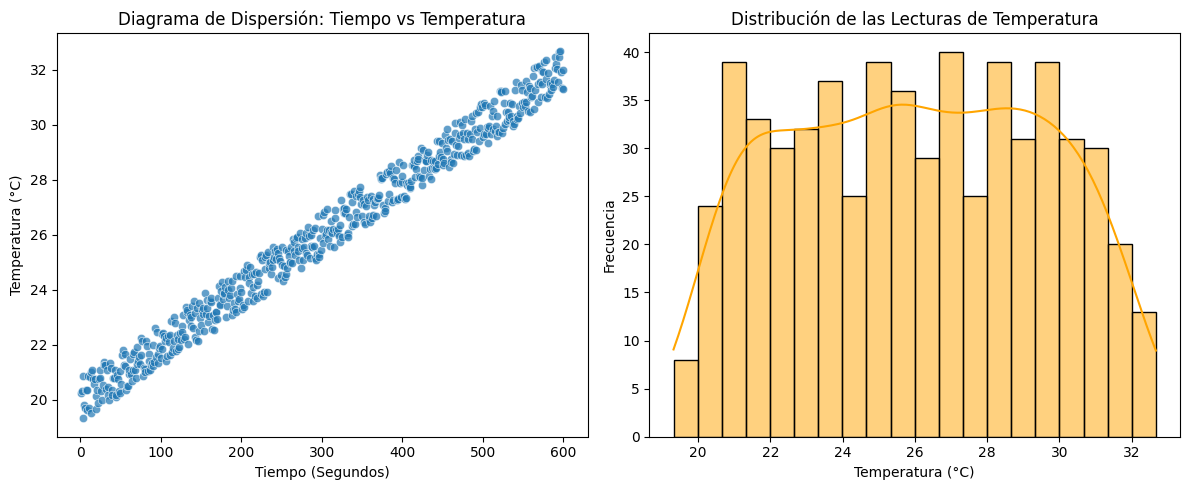

In [8]:
def analisisExploratorioDatos(x, y):
    df_sensor = pd.DataFrame({
        'Tiempo_s': x.flatten(),
        'Temperatura_C': y.flatten()
    })

    print("--- INFORMACIÓN DEL SENSOR ---")
    df_sensor.info()

    print("\n--- ESTADÍSTICOS DESCRIPTIVOS ---")
    display(df_sensor.describe().round(2))

    print("\n--- CORRELACIÓN ---")
    display(df_sensor.corr().round(3))

    # 2. Visualización: Dispersión y Distribución
    plt.figure(figsize=(12, 5))

    # Gráfico 1: Nube de puntos (Comprobando la tendencia lineal)
    plt.subplot(1, 2, 1)
    sns.scatterplot(data=df_sensor, x='Tiempo_s', y='Temperatura_C', alpha=0.7)
    plt.title('Diagrama de Dispersión: Tiempo vs Temperatura')
    plt.xlabel('Tiempo (Segundos)')
    plt.ylabel('Temperatura (°C)')

    # Gráfico 2: Histograma
    plt.subplot(1, 2, 2)
    sns.histplot(data=df_sensor, x='Temperatura_C', bins=20, kde=True, color='orange')
    plt.title('Distribución de las Lecturas de Temperatura')
    plt.xlabel('Temperatura (°C)')
    plt.ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()

analisisExploratorioDatos(x, y)

Como solamente se tiene un atributo (Tiempo) y el valor que queremos predecir (Temperatura). Como no hay nulos, no hay variables categóricas, no hay características redundantes (correlacionadas entre sí) y los algoritmos de regresión simple manejan la escala original sin problema, entoces se puede pasar los datos crudos a `LinearRegression` directamente después del EDA.

---

## **El segundo paso**

El segundo paso será implementar una función que realice toda esta parte de la práctica: que tome estos datos generados y que haga lo siguiente.



1) Adaptar los datos de entrada X para la entrada `LinearRegression`. En la x, se necesita $[[1],[2], …]$ en vez de $[1, 2, …]$. Se puede hacer con las $List\ Comprehensions$.

2) Obtener el coeficiente de la función lineal aprendida y la parte independiente (i.e. `intercept`), y mostrarlos por pantalla.

3) Obtener los datos “y” (e.g. `yLinealResult`) de la función lineal aprendida.

4) Usar `Matplotlib` para mostrar los puntos de mediciones de temperatura generados y la función lineal aprendida.


### 1. Adaptar datos **X** usando $List\ Comprehension$
> Nota: Convertimos $[1, 2, 3]$ en $[[1], [2], [3]]$


In [9]:
X_modelo = [[instante] for instante in x]

# Datos (Scikit-learn requiere que X sea una matriz de 2 dimensiones)
#x_modelo = np.array(x).reshape(-1, 1)

### 2. Configurar y entrenar el modelo de **Regresión Lineal**

In [10]:
modelo = LinearRegression()
modelo.fit(X_modelo, y)

LinearRegression()

* #### Obtener coeficientes
> Nota: Pendiente de la recta e intersección con el eje **y**



In [11]:
m = modelo.coef_[0]
b = modelo.intercept_

* #### Mostrar coeficientes

In [12]:
print(f"--- Resultados del Aprendizaje ---")
print(f"Coeficiente (m - Pendiente): {m:.4f}")
print(f"Término independiente (b - Intercept): {b:.4f}")
print(f"Ecuación aprendida: y = {m:.4f}x + {b:.4f}")

--- Resultados del Aprendizaje ---
Coeficiente (m - Pendiente): 0.0200
Término independiente (b - Intercept): 19.9821
Ecuación aprendida: y = 0.0200x + 19.9821


### 3. Obtener las predicciones (`yLinealResult`)


In [13]:
yLinealResult = modelo.predict(X_modelo)

> Nota: Calcular error para saber que tan bueno es modelo

In [14]:
# Puedes calcular el error medio
y_train = np.array(y)
error = mean_squared_error(y_train, yLinealResult)
#print(f"El valor y_train: {y_train}")
print(f"Mi modelo tiene un error de: {error}")

Mi modelo tiene un error de: 0.22148442077031733


> Nota: Ejemplo de calculo de un nuevo valor

In [15]:
# Calcular nuevo valor
nuevo_x = np.array([[777]])
pred_nuevo = modelo.predict(nuevo_x)
print(f"Predicción para 12 minutos aproximado: {pred_nuevo[0]:.2f}")

Predicción para 12 minutos aproximado: 35.49


### 4. Visualización con **Matplotlib**


In [16]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

* #### Mostrar puntos de mediciones (con ruido)

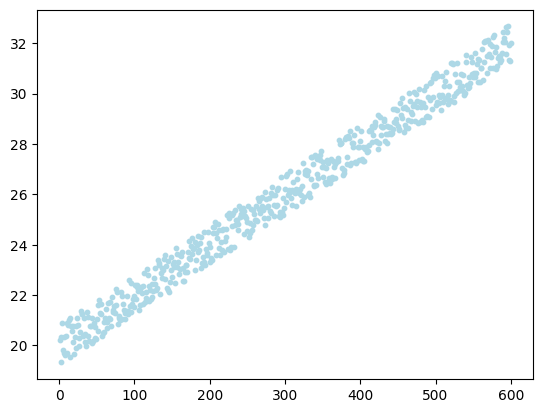

In [17]:
plt.scatter(x, y, color='lightblue', s=10, label='Mediciones del Sensor (con ruido)')

* #### Mostrar la función lineal aprendida

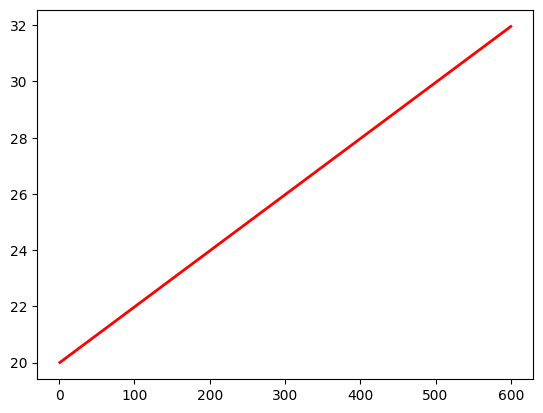

In [18]:
plt.plot(x, yLinealResult, color='red', linewidth=2, label='Tendencia Lineal Aprendida')

* #### Configuración de etiquetas

/tmp/ipython-input-334/2630296469.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


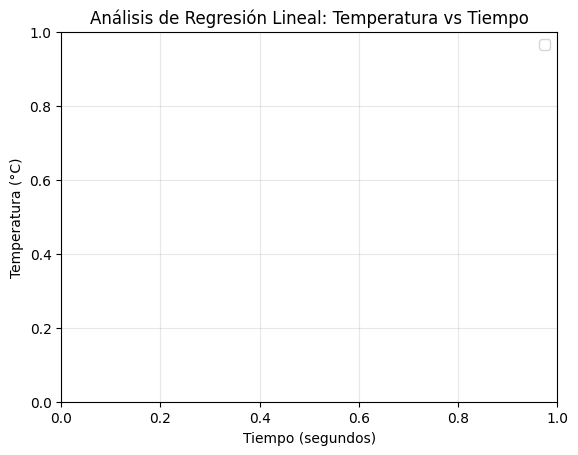

In [19]:
plt.title('Análisis de Regresión Lineal: Temperatura vs Tiempo')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5. Atributos Post-Entrenamiento (Atributos con guion bajo)

* **coef\_ y intercept\_**: Son los más fundamentales. Representan la pendiente ($m$) y la intersección ($b$) de la fórmula $y = mx + b$. Lo fascinante es que, en una **Regresión Lineal Múltiple**, coef\_ se convierte en un array que contiene un peso para cada variable de entrada ($b_1, b_2, \dots, b_n$).  

### 6. Función definida `procesarRegresionTemperatura(x, y)`

--- Resultados del Aprendizaje ---
Coeficiente (m - Pendiente): 0.0200
Término independiente (b - Intercept): 19.9821
Ecuación aprendida: y = 0.0200x + 19.9821


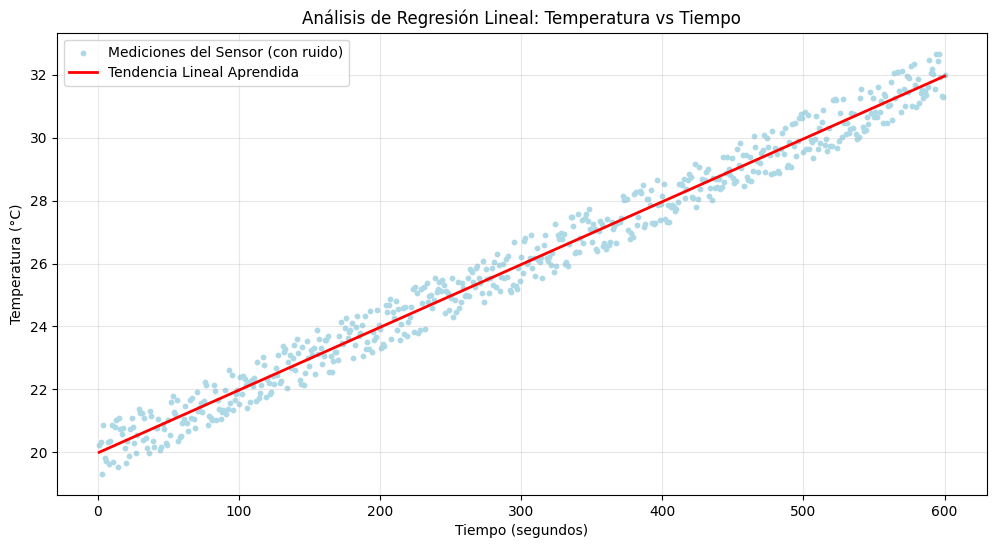

In [20]:
def procesarRegresionTemperatura(x, y):
    X_modelo = [[instante] for instante in x]

    modelo = LinearRegression()
    modelo.fit(X_modelo, y)

    m = modelo.coef_[0]
    b = modelo.intercept_

    print(f"--- Resultados del Aprendizaje ---")
    print(f"Coeficiente (m - Pendiente): {m:.4f}")
    print(f"Término independiente (b - Intercept): {b:.4f}")
    print(f"Ecuación aprendida: y = {m:.4f}x + {b:.4f}")

    yLinealResult = modelo.predict(X_modelo)

    plt.figure(figsize=(12, 6))

    plt.scatter(x, y, color='lightblue', s=10, label='Mediciones del Sensor (con ruido)')

    plt.plot(x, yLinealResult, color='red', linewidth=2, label='Tendencia Lineal Aprendida')

    plt.title('Análisis de Regresión Lineal: Temperatura vs Tiempo')
    plt.xlabel('Tiempo (segundos)')
    plt.ylabel('Temperatura (°C)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

procesarRegresionTemperatura(x, y)
